### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [96]:
!pip install koreanize-matplotlib

### 라이브러리 import

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 분할

In [98]:
# Feature(X)와 Target(y) 분리
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print(X.shape)

(442, 10)


### 2. 데이터 전처리

In [99]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"스케일링된 데이터 형태: {X_scaled.shape}")

스케일링된 데이터 형태: (442, 10)


### 3. PCA 모델 생성 및 적용

In [100]:
# 2개의 주성분으로 축소
pca = PCA(n_components=X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)

print(f"PCA 변환 후 차원: {X_pca.shape}")
print(f"주성분별 설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산 비율: {np.sum(pca.explained_variance_ratio_):.4f}")

PCA 변환 후 차원: (442, 10)
주성분별 설명된 분산 비율: [0.40242108 0.14923197 0.12059663 0.09554764 0.06621814 0.06027171
 0.05365657 0.0433682  0.007832   0.00085607]
총 설명된 분산 비율: 1.0000


### 4. 최적의 주성분 갯수 결정 (Scree Plot)

In [101]:
# 전체 주성분에 대한 PCA 수행
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)

# 설명된 분산 비율 및 누적 분산 비율 계산
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

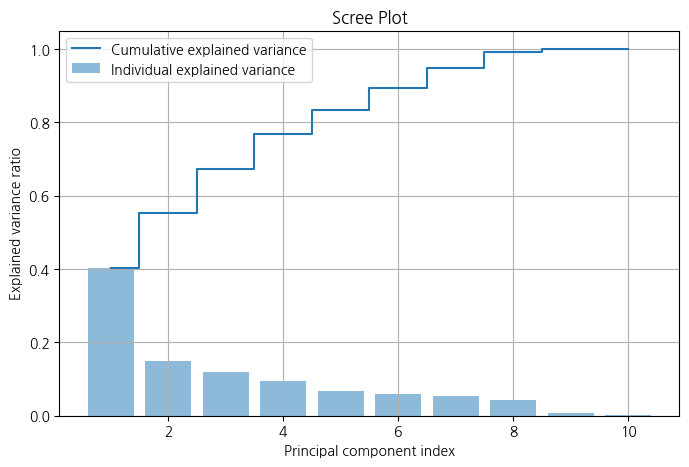

In [102]:
# Scree Plot 시각화
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center',
        label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### 5. PCA 변환 결과 시각화

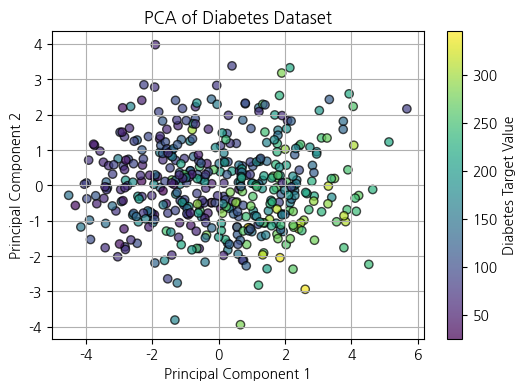

In [103]:
plt.figure(figsize=(6, 4))
# Outcome(당뇨병 발병 여부)에 따라 색상 구분 (0: 정상, 1: 당뇨)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Diabetes Dataset')
plt.colorbar(scatter, label='Diabetes Target Value')
plt.grid(True)
plt.show()